<a href="https://colab.research.google.com/github/Marconi-Lab/Solar_irradiation/blob/rm%2FCBE_data/CBE_Data_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA for CBE Data
- Having a look at Cross Boundary Enery Data


In [2]:
import pvlib
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from ydata_profiling import ProfileReport

# Extracting CBE data

In [3]:
with zipfile.ZipFile('Data/CBE.zip') as z:
    with z.open('CBE/CBE_Egypt.csv') as f1:
        df_egypt = pd.read_csv(f1)
    with z.open('CBE/CBE_Ghana.csv') as f2:
        df_ghana = pd.read_csv(f2)
    with z.open('CBE/CBE_Kenya.csv') as f3:
        df_kenya = pd.read_csv(f3)
    with z.open('CBE/CBE_Nigeria.csv') as f4:
        df_nigeria = pd.read_csv(f4)
    with z.open('CBE/CBE_Madagascar.csv') as f5:
        df_madagascar = pd.read_csv(f5)
    with z.open('CBE/CBE_Somalia.csv') as f6:
        df_somalia = pd.read_csv(f6)

In [76]:
## Class to handle multiple locations one at a time 
from timezonefinder import TimezoneFinder
from datetime import datetime
import pytz
from geopy.geocoders import Nominatim

class Location:
    def __init__(self, latitude : float, longitude : float,
                 altitude : float = None, timezone : str = None,
                 name : str = None):
        
        self.latitude = latitude
        self.longitude = longitude
        
        if altitude is None:
            self.altitude = pvlib.location.altitude(latitude, longitude)
        else:
            self.altitude = altitude

        if timezone is None:
            self.timezone = self.find_timezone()
        elif isinstance(timezone, str):
            self.timezone = pytz.timezone(timezone)
        elif isinstance(timezone, pytz.timezone):
            self.timezone = timezone
        elif isinstance(timezone, datetime):
            self.timezone = pytz.timezone(timezone.tzinfo.zone)
        else:
            raise ValueError('Invalid timezone input')
        
        if name is None:
            self.name = self.find_name()
    
    def find_timezone(self):
        tf = TimezoneFinder()
        return pytz.timezone(tf.timezone_at(lng=self.longitude, lat=self.latitude))
    
    def find_name(self):
        geolocator = Nominatim(user_agent='solar')
        location = geolocator.reverse(f"{self.latitude}, {self.longitude}")
        return location.address

In [ ]:
class LocationHandler:
    def __init__(self, name: str, dataframe: pd.DataFrame):
        """
        Handles data for a specific location
        """
        self.name = name
        self._dataframe = dataframe

    @property
    def dataframe(self) -> pd.DataFrame:
        df = self._dataframe.copy()
        df.set_index('MEASURE_DATE', inplace=True)
        df.index = pd.to_datetime(df.index)
        df.sort_index(inplace=True)
        
        df.drop(columns=['DIM_SITE_ID', 'SITE_LATITUDE', 'SITE_LONGITUDE', 'Location_Name'], inplace=True)
        
        return df

    @property
    def ghi(self) -> np.ndarray:
        return self._dataframe['MEASURE_VALUE'].values
    
    @property
    def coordinates(self) -> tuple:
        return (self._dataframe['SITE_LATITUDE'].values[0], self._dataframe['SITE_LONGITUDE'].values[0]) 
    
    @property
    def timezone(self) -> str:
           


class DataHandler:
    def __init__(self, dataframe: pd.DataFrame):
        self._dataframe = dataframe
        self._locations = {}
        self._add_location_labels()

        for location_label in self._dataframe['Location_Label'].unique():
            location_df = dataframe[dataframe['Location_Label'] == location_label]
            self._locations[location_label] = LocationHandler(location_label, location_df)
            setattr(self, location_label, self._locations[location_label])

    def _add_location_labels(self):
        geolocator = Nominatim(user_agent="solar")

        def get_location_name(row):
            location = geolocator.reverse((row['SITE_LATITUDE'], row['SITE_LONGITUDE']))
            location_str = location.address
            location_components = location_str.split(', ')
            location_name = str(location_components[0]).replace(' ', '_').lower()
            location_name = str(location_name).replace('-', '_').lower()
            return location_name

        unique_site_ids = self._dataframe[['DIM_SITE_ID', 'SITE_LATITUDE', 'SITE_LONGITUDE']].drop_duplicates()

        location_names = {}
        for _, row in unique_site_ids.iterrows():
            location_name = get_location_name(row)
            if location_name in location_names.values():
                suffix = 'a'
                while f"{location_name}_{suffix}" in location_names.values():
                    suffix = chr(ord(suffix) + 1)
                location_name = f"{location_name}_{suffix}"
            location_names[row['DIM_SITE_ID']] = location_name

        location_labels = {}
        for i, location in enumerate(location_names.values()):
            location_labels[location] = f"area_{chr(97 + i)}"

        self._dataframe['Location_Name'] = self._dataframe['DIM_SITE_ID'].map(location_names)
        self._dataframe['Location_Label'] = self._dataframe['Location_Name'].map(location_labels)
    
    @property
    def locations(self):
        return self._dataframe['Location_Label'].unique()

In [58]:
kenya = DataHandler(df_kenya)

In [59]:
kenya.locations

array(['area_a', 'area_b', 'area_c', 'area_d', 'area_e', 'area_f',
       'area_g', 'area_h', 'area_i', 'area_j', 'area_k', 'area_l',
       'area_m', 'area_n', 'area_o', 'area_p', 'area_q', 'area_r'],
      dtype=object)

In [61]:
kenya.area_b.dataframe

,MEASURE_VALUE,SITE_COUNTRY,Location_Label
MEASURE_DATE,,,
2023-10-01,0.000,Kenya,area_b
2023-10-02,0.000,Kenya,area_b
2023-10-03,0.000,Kenya,area_b
2023-10-04,0.000,Kenya,area_b
2023-10-05,0.000,Kenya,area_b
...,...,...,...
2024-11-27,2362.332,Kenya,area_b
2024-11-28,4579.593,Kenya,area_b
2024-11-29,4147.007,Kenya,area_b


In [52]:
kenya.area_a.ghi()

array([5.60061200e+03, 2.02949050e+03, 0.00000000e+00, 4.00769017e+03,
       4.84917967e+03, 4.19683300e+03, 4.72831683e+03, 0.00000000e+00,
       4.28099467e+03, 0.00000000e+00, 0.00000000e+00, 5.85291700e+03,
       5.88258967e+03, 0.00000000e+00, 5.13945450e+03, 0.00000000e+00,
       7.09008300e+03, 4.90662500e+03, 5.78044867e+03, 0.00000000e+00,
       6.66123183e+03, 4.49448750e+03, 0.00000000e+00, 5.94900000e+03,
       4.81745800e+03, 3.05793017e+03, 5.34895800e+03, 5.44070933e+03,
       0.00000000e+00, 4.90037500e+03, 3.93975000e+03, 6.48652067e+03,
       0.00000000e+00, 0.00000000e+00, 4.60434167e+03, 0.00000000e+00,
       5.26979200e+03, 5.82420800e+03, 4.54883300e+03, 3.24599083e+03,
       7.24158300e+03, 5.88015550e+03, 2.86545800e+03, 0.00000000e+00,
       4.55006700e+03, 0.00000000e+00, 0.00000000e+00, 4.29824967e+03,
       5.00866700e+03, 7.09500000e+03, 4.79890567e+03, 4.98266700e+03,
       0.00000000e+00, 4.77150000e+03, 4.23450000e+03, 6.71338850e+03,
      

In [25]:
# # Replace the DIM_SITE_ID with the location name
# df_kenya.drop(columns=['DIM_SITE_ID'], inplace=True)
# df_kenya.rename(columns={'Location_Name': 'DIM_SITE_ID'}, inplace=True)

df_kenya.head(30)

,DIM_SITE_ID,MEASURE_DATE,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,Location_Name,Location_Label
0,16866539966093067829,2024-09-18,5600.612000,Kenya,-1.451111,36.975687,kcb_atm___athi_river,area_a
1,1720018612255308305,2024-09-18,4343.791000,Kenya,-1.491302,37.052862,mombasa_nairobi_road,area_b
2,6961463658566967421,2024-09-18,6814.195000,Kenya,-0.469974,35.181874,jamji,area_c
3,14677532269409350870,2024-09-18,5812.226000,Kenya,-0.400000,35.920000,matigari,area_d
4,11347099494983858833,2024-09-18,6391.284000,Kenya,-0.220000,35.860000,tegat,area_e
5,11347099494983858833,2024-09-18,6391.284000,Kenya,-0.220000,35.860000,tegat,area_e
6,11106529797326926225,2024-09-18,4917.127000,Kenya,-1.494448,37.057094,mombasa_nairobi_road_a,area_f
7,3714152719648338910,2024-09-18,5267.384000,Kenya,-1.491302,37.052862,mombasa_nairobi_road_b,area_g
8,16388039360858303205,2024-09-18,6378.369000,Kenya,-0.220000,35.860000,tegat_a,area_h
9,8705757164558664589,2024-09-18,7675.126000,Kenya,-0.227185,35.884984,nairobi_road,area_i


In [ ]:


# Initialize the TimezoneFinder
tf = TimezoneFinder()

# Example coordinates (latitude, longitude)
latitude = 1.2921
longitude = 36.8219

# Find the time zone name
timezone_str = tf.timezone_at(lng=longitude, lat=latitude)

# Get the time zone object
timezone = pytz.timezone(timezone_str)

# Get the current time in the specified time zone
current_time = datetime.now(timezone)

print(f"Time zone: {timezone_str}")
print(f"Current time: {current_time}")


Time zone: Africa/Nairobi
Current time: 2024-12-05 13:27:33.829169+03:00


In [56]:
print(timezone_str)

Africa/Nairobi


In [57]:
print(f"timezone string type: {type(timezone_str)}")
print(f"timezone object type: {type(timezone)}")

timezone string type: <class 'str'>
timezone object type: <class 'pytz.tzfile.Africa/Nairobi'>


## Egypt

In [45]:
df_egypt.head()

,DIM_SITE_ID,MEASURE_DATE,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
0,4457035132449260732,2024-10-02,4843.371,Egypt,29.887561,32.460447
1,4457035132449260732,2024-10-15,3846.652,Egypt,29.887561,32.460447
2,4457035132449260732,2024-10-22,4050.359,Egypt,29.887561,32.460447
3,4457035132449260732,2024-10-30,3342.204,Egypt,29.887561,32.460447
4,4457035132449260732,2024-11-02,3157.146,Egypt,29.887561,32.460447


In [46]:
egypt = DataHandler(df_egypt)
df = egypt.get_dataframe()

In [47]:
df.head()

,GHI (Wh/m2)
MEASURE_DATE,
2024-10-02,4843.371
2024-10-15,3846.652
2024-10-22,4050.359
2024-10-30,3342.204
2024-11-02,3157.146


In [48]:
egypt.ghi()

array([4843.371, 3846.652, 4050.359, 3342.204, 3157.146, 3070.041,
       2991.062, 4607.663, 4379.561, 3697.176, 4005.771, 3776.212,
       3193.649, 2803.461, 1239.064, 2743.356, 4878.783, 4997.191,
       4557.843, 4664.688, 4596.721, 4048.264, 4197.546, 3901.068,
       3051.053, 3036.26 , 2891.387, 4952.211, 5126.845, 5025.155,
       4594.78 , 7267.446, 4972.714, 6028.856, 5139.49 , 7245.663,
       3519.684, 3039.883, 3555.166, 5314.898, 4819.333, 5484.176,
       5764.704, 2676.1  , 3018.766, 2604.205, 5043.374, 3532.831,
       6922.845, 4477.044, 5388.585, 6962.795, 7067.417, 5118.058,
       4496.79 , 4717.823, 3223.318, 4617.091, 3245.26 , 5294.954,
       5881.154, 3294.357, 5479.843, 5088.66 , 6405.046, 5180.499,
       5255.338, 5286.113, 3665.842, 4566.202, 4078.106, 6992.601,
       3729.689, 7303.878, 3213.52 , 3279.451, 6805.787, 5873.937,
       5212.635, 6600.638, 5057.016, 7286.434, 3458.82 , 6122.273,
       5513.359, 7016.888, 3608.021, 3151.732, 4409.043, 3749.

## Kenya

In [49]:
df_kenya.head()

,DIM_SITE_ID,MEASURE_DATE,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
0,16866539966093067829,2024-09-18,5600.612,Kenya,-1.451111,36.975687
1,1720018612255308305,2024-09-18,4343.791,Kenya,-1.491302,37.052862
2,6961463658566967421,2024-09-18,6814.195,Kenya,-0.469974,35.181874
3,14677532269409350870,2024-09-18,5812.226,Kenya,-0.400000,35.920000
4,11347099494983858833,2024-09-18,6391.284,Kenya,-0.220000,35.860000


In [50]:
kenya = DataHandler(df_kenya)
df = kenya.get_dataframe()
df.head()

,DIM_SITE_ID,GHI (Wh/m2),SITE_LATITUDE,SITE_LONGITUDE
MEASURE_DATE,,,,
2024-09-18,16866539966093067829,5600.612,-1.451111,36.975687
2024-09-18,1720018612255308305,4343.791,-1.491302,37.052862
2024-09-18,6961463658566967421,6814.195,-0.469974,35.181874
2024-09-18,14677532269409350870,5812.226,-0.400000,35.920000
2024-09-18,11347099494983858833,6391.284,-0.220000,35.860000


## Profile reports of the data

In [3]:
profile = ProfileReport(df_somalia, tsmode=True,title="Somalia")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

/home/mukiibirogers/GitHub/Solar_irradiation/.susse_venv/lib64/python3.12/site-packages/ydata_profiling/model/pandas/describe_timeseries_pandas.py:98: RuntimeWarning: divide by zero encountered in log10
  ampl = 10 * np.log10(data_psd[pos_freq_ix])


ValueError: Invalid input, x is constant

In [ ]:
profile = ProfileReport(df_egypt, title="Egypt")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile = ProfileReport(df_kenya, title="Kenya")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile = ProfileReport(df_ghana, title="Ghana")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile = ProfileReport(df_nigeria, title="Nigeria")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile = ProfileReport(df_madagascar, title="Madagascar")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Focusing on Egypt data

Why
*   It has one location (similar coordinates)
*   So I can look at the location and compare the data



In [ ]:
df_egypt = pd.read_csv('/content/drive/MyDrive/GIZ_Irradiation_Project/Working Folder/models/CBE_Data/CBE_Egypt.csv')
latitude = df_egypt['SITE_LATITUDE'].unique()[0]
longitude = df_egypt['SITE_LONGITUDE'].unique()[0]
altitude = pvlib.location.lookup_altitude(
    latitude=latitude,
    longitude=longitude
)

print(f"Latitude: {latitude}\nLongitude: {longitude}\nAltitude: {altitude}")

df_egypt.index = pd.to_datetime(df_egypt['MEASURE_DATE'])
df_egypt.index.name = 'Date'
df_egypt.drop(columns=['SITE_LATITUDE', 'SITE_LONGITUDE', 'MEASURE_DATE', 'SITE_COUNTRY'], inplace=True)
df_egypt.rename(columns={'MEASURE_VALUE': 'ghi_ground'}, inplace=True)
df_egypt.sort_index(inplace=True)

Latitude: 29.887561
Longitude: 32.460447
Altitude: 110.0


In [ ]:
df_egypt.head()

,ghi_ground
Date,
2023-09-01,6428.052
2023-09-02,6601.826
2023-09-03,6600.638
2023-09-04,6391.094
2023-09-05,6373.021


In [ ]:
egypt = pvlib.location.Location(
    latitude=latitude,
    longitude=longitude,
    tz='Africa/Cairo',
    altitude=altitude
)

email = 'mukiibirogerz@gmail.com'

In [ ]:
df_egypt

,ghi_ground
Date,
2023-09-01,6428.052
2023-09-02,6601.826
2023-09-03,6600.638
2023-09-04,6391.094
2023-09-05,6373.021
...,...
2024-11-21,2027.863
2024-11-22,3016.563
2024-11-23,2803.461


In [ ]:
# start and end date of the data frame
start_date = df_egypt.index.min().date()
end_date = df_egypt.index.max().date()

print(f"Start date: {start_date}\nEnd date: {end_date}")

Start date: 2023-09-01
End date: 2024-11-25


### CAMS RAD data

In [ ]:
df, metadata = pvlib.iotools.get_cams(
    latitude=egypt.latitude,
    longitude=egypt.longitude,
    start=start_date,
    end=end_date,
    email=email,
    identifier="cams_radiation",
    altitude=egypt.altitude,
    time_step='1d'
)

In [ ]:
df.index.name = 'Date'
df_cams = df['ghi']
df_cams.name = 'ghi_cams'
df_cams.head()

,ghi_cams
Date,
2023-09-01,294.337200
2023-09-02,308.243042
2023-09-03,297.043642
2023-09-04,305.370950
2023-09-05,303.647075


In [ ]:
df_egypt = pd.concat([df_egypt, df_cams], axis=1)
df_egypt.head()

,ghi_ground,ghi_cams
Date,,
2023-09-01,6428.052,294.337200
2023-09-02,6601.826,308.243042
2023-09-03,6600.638,297.043642
2023-09-04,6391.094,305.370950
2023-09-05,6373.021,303.647075


In [ ]:
df_egypt.describe()

,ghi_ground,ghi_cams
count,452.000000,452.000000
mean,5047.538478,244.551257
std,1486.092013,78.014612
min,1239.064000,61.244083
25%,3704.935750,176.752570
50%,5057.728000,251.370423
75%,6405.323000,314.941244
max,7675.660000,368.944050


### Solcast data

In [ ]:
# opening zipfile
import zipfile

with zipfile.ZipFile('batch_91ef1a13-4fef-402f-bede-8bbf1a7b0154.zip') as z:
    with z.open('csv_29.887561_32.460447_fixed_27_180_PT60M.csv') as f:
        df1 = pd.read_csv(f)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16584 entries, 0 to 16583
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   air_temp               16584 non-null  int64  
 1   albedo                 16584 non-null  float64
 2   azimuth                16584 non-null  int64  
 3   clearsky_dhi           16584 non-null  int64  
 4   clearsky_dni           16584 non-null  int64  
 5   clearsky_ghi           16584 non-null  int64  
 6   clearsky_gti           16584 non-null  int64  
 7   cloud_opacity          16584 non-null  float64
 8   dewpoint_temp          16584 non-null  float64
 9   dhi                    16584 non-null  int64  
 10  dni                    16584 non-null  int64  
 11  ghi                    16584 non-null  int64  
 12  gti                    16584 non-null  int64  
 13  precipitable_water     16584 non-null  float64
 14  precipitation_rate     16584 non-null  float64
 15  re

In [ ]:
df1.head()

,air_temp,albedo,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,cloud_opacity,dewpoint_temp,dhi,...,wind_direction_100m,wind_direction_10m,wind_speed_100m,wind_speed_10m,zenith,cape,snowfall_rate,wind_gust,period_end,period
0,13,0.31,-88,0,0,0,0,42.5,10.3,0,...,342,324,3.5,2.5,144,0,0,4.9,2023-01-01T01:00:00+00:00,PT60M
1,12,0.31,-96,0,0,0,0,63.9,10.0,0,...,338,322,3.8,2.7,131,0,0,5.2,2023-01-01T02:00:00+00:00,PT60M
2,12,0.31,-102,0,0,0,0,75.7,9.8,0,...,336,322,4.2,2.8,119,0,0,5.4,2023-01-01T03:00:00+00:00,PT60M
3,12,0.31,-108,0,0,0,0,45.1,10.0,0,...,334,319,4.3,2.8,106,0,0,5.5,2023-01-01T04:00:00+00:00,PT60M
4,12,0.31,-115,1,0,1,1,25.1,10.3,0,...,332,316,4.2,2.8,94,0,0,5.7,2023-01-01T05:00:00+00:00,PT60M


In [ ]:
df1.index = pd.to_datetime(df1['period_end'])
df1.index.name = 'Date'
df1

,air_temp,albedo,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,cloud_opacity,dewpoint_temp,dhi,...,wind_direction_100m,wind_direction_10m,wind_speed_100m,wind_speed_10m,zenith,cape,snowfall_rate,wind_gust,period_end,period
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-01 01:00:00+00:00,13,0.31,-88,0,0,0,0,42.5,10.3,0,...,342,324,3.5,2.5,144,0,0,4.9,2023-01-01T01:00:00+00:00,PT60M
2023-01-01 02:00:00+00:00,12,0.31,-96,0,0,0,0,63.9,10.0,0,...,338,322,3.8,2.7,131,0,0,5.2,2023-01-01T02:00:00+00:00,PT60M
2023-01-01 03:00:00+00:00,12,0.31,-102,0,0,0,0,75.7,9.8,0,...,336,322,4.2,2.8,119,0,0,5.4,2023-01-01T03:00:00+00:00,PT60M
2023-01-01 04:00:00+00:00,12,0.31,-108,0,0,0,0,45.1,10.0,0,...,334,319,4.3,2.8,106,0,0,5.5,2023-01-01T04:00:00+00:00,PT60M
2023-01-01 05:00:00+00:00,12,0.31,-115,1,0,1,1,25.1,10.3,0,...,332,316,4.2,2.8,94,0,0,5.7,2023-01-01T05:00:00+00:00,PT60M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-21 20:00:00+00:00,19,0.19,78,0,0,0,0,39.8,7.8,0,...,12,5,2.9,2.5,150,0,0,2.7,2024-11-21T20:00:00+00:00,PT60M
2024-11-21 21:00:00+00:00,19,0.19,59,0,0,0,0,21.5,7.7,0,...,4,354,2.7,2.3,162,0,0,2.5,2024-11-21T21:00:00+00:00,PT60M
2024-11-21 22:00:00+00:00,19,0.19,8,0,0,0,0,25.1,7.7,0,...,355,346,2.8,2.5,169,0,0,2.6,2024-11-21T22:00:00+00:00,PT60M


In [ ]:
df_sol = df1['ghi']
df_sol.name = 'ghi_sol'
df_sol.tail(24)

,ghi_sol
Date,
2024-11-21 01:00:00+00:00,0
2024-11-21 02:00:00+00:00,0
2024-11-21 03:00:00+00:00,0
2024-11-21 04:00:00+00:00,0
2024-11-21 05:00:00+00:00,20
2024-11-21 06:00:00+00:00,173
2024-11-21 07:00:00+00:00,358
2024-11-21 08:00:00+00:00,509
2024-11-21 09:00:00+00:00,623


In [ ]:
def calculate_daily_irradiation(dataframe):
    """
    Calculate the daily sum of GHI (global horizontal irradiation) from the dataframe.

    Parameters:
        dataframe (pd.DataFrame): A pandas DataFrame containing a datetime index and a column 'ghi_sol'.

    Returns:
        pd.Series: A pandas Series where the index is the date and the values are the daily sum of GHI.
    """
    # Ensure the index is a datetime object
    dataframe.index = pd.to_datetime(dataframe.index)
    dataframe.sort_index(inplace=True)

    # Resample the data to daily frequency, summing the 'ghi_sol' values
    daily_irradiation = dataframe.resample('D').sum()

    return daily_irradiation

In [ ]:
df_daily_sol = calculate_daily_irradiation(df_sol)
df_daily_sol.index = df_daily_sol.index.date
df_daily_sol.head()

,ghi_sol
2023-01-01,3402
2023-01-02,3488
2023-01-03,3476
2023-01-04,2392
2023-01-05,3824


In [ ]:
# trancate the df_daily_sol from start to end date

df_daily_sol = df_daily_sol.loc[start_date:end_date]
df_daily_sol = df_daily_sol.to_frame()
df_daily_sol.index.name = 'Date'
df_daily_sol.tail()

,ghi_sol
Date,
2024-11-18,4000
2024-11-19,3444
2024-11-20,3901
2024-11-21,3975
2024-11-22,0


In [ ]:
df_daily_sol = df_daily_sol.reindex(df_egypt.index)

In [ ]:
# merege the two dfs df_daily_sol and df_egypt
df_comb = pd.concat([df_egypt, df_daily_sol], axis=1)
df_comb.dropna(inplace=True)
df_comb.head()

,ghi_ground,ghi_sol
Date,,
2023-09-01,6428.052,6743.0
2023-09-02,6601.826,6944.0
2023-09-03,6600.638,6925.0
2023-09-04,6391.094,6831.0
2023-09-05,6373.021,7071.0


In [ ]:
df_comb.tail()

,ghi_ground,ghi_sol
Date,,
2024-11-18,3226.724,4000.0
2024-11-19,3185.315,3444.0
2024-11-20,2811.545,3901.0
2024-11-21,2027.863,3975.0
2024-11-22,3016.563,0.0


In [ ]:
profile = ProfileReport(df_comb, title="Egypt")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

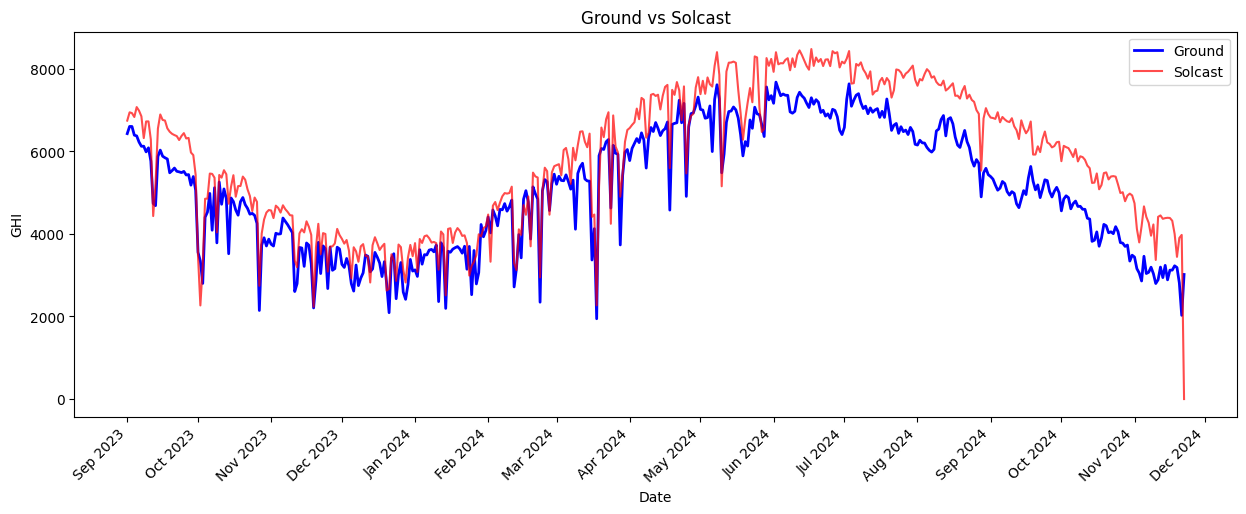

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 5))

ax1 = ax
ax1.plot(df_comb.index, df_comb['ghi_ground'], label='Ground', linewidth=2, color='blue')
ax1.plot(df_comb.index, df_comb['ghi_sol'], label='Solcast', alpha=0.7, color='red')
ax1.set_title('Ground vs Solcast')
ax1.set_xlabel('Date')
ax1.set_ylabel('GHI')
ax1.legend()
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

plt.show()